# US District Microgrid Dataset

This notebook contains data exploration for a US District Microgrid Dataset: https://github.com/FLYao123/District-microgrid-dataset, reference from the paper: "A Holistic Power Optimization Approach for Microgrid Control Based
on Deep Reinforcement Learning"


In [15]:
# Importing a few important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv('Microgrid data.csv')

In [5]:
data

,Timestamp,price (dollar/kWh),Unmeet(kWh),CI(gco2/kWh),Load (kWh),PV (kWh)
0,2012/1/1 0:00,0.3168,2698.000000,184,2698,0.000000
1,2012/1/1 1:00,0.2988,2558.000000,182,2558,0.000000
2,2012/1/1 2:00,0.2701,2444.000000,171,2444,0.000000
3,2012/1/1 3:00,0.2606,2402.000000,169,2402,0.000000
4,2012/1/1 4:00,0.2564,2403.000000,159,2403,0.000000
...,...,...,...,...,...,...
8779,2012/12/31 19:00,0.8394,3768.741712,126,3769,0.258288
8780,2012/12/31 20:00,0.7951,3585.000000,115,3585,0.000000
8781,2012/12/31 21:00,0.7313,3407.000000,99,3407,0.000000
8782,2012/12/31 22:00,0.7010,3219.000000,85,3219,0.000000


This particular csv contains a year's data on Price of Electricity from main grid, PV Generation (Solar), Carbon Emissions per kWh of Electricity produced, Load Demand data and unmeet data (Load - PV Generation)

In [6]:
data.columns # check the columns of this csv

Index(['Timestamp', 'price (dollar/kWh)', 'Unmeet(kWh)', 'CI(gco2/kWh)',
       'Load (kWh)', 'PV (kWh)'],
      dtype='object')

In [7]:
data.describe() # general statistics of the data

,price (dollar/kWh),Unmeet(kWh),CI(gco2/kWh),Load (kWh),PV (kWh)
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,0.387689,2907.333239,187.391849,3255.071380,347.738141
std,0.150264,590.708360,59.218272,567.993958,526.375913
min,0.125200,1368.042829,39.000000,1979.000000,0.000000
25%,0.288975,2456.000000,143.000000,2798.750000,0.000000
50%,0.360900,2857.289848,193.000000,3316.000000,8.781816
75%,0.455625,3321.629896,233.000000,3641.000000,561.067671
max,1.000000,4763.684513,345.000000,4912.000000,1796.010614


In [9]:
data.isna().sum() # data contains no null values

,0
Timestamp,0
price (dollar/kWh),0
Unmeet(kWh),0
CI(gco2/kWh),0
Load (kWh),0
PV (kWh),0


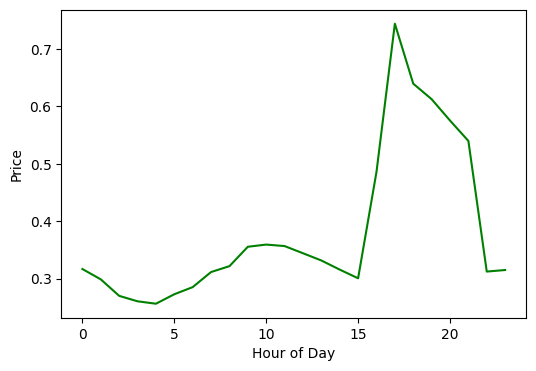

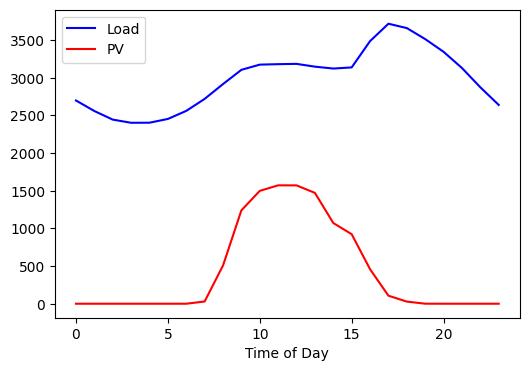

In [14]:
# Let's look at a day's data variables plotted
jan_first_data = data[:24]
jan_first_data

plt.figure(figsize=(6, 4))
plt.plot(jan_first_data.index, jan_first_data['price (dollar/kWh)'], color='green')
plt.xlabel('Hour of Day')
plt.ylabel('Price')

plt.figure(figsize=(6, 4))
plt.plot(jan_first_data.index, jan_first_data['Load (kWh)'], label='Load', color='blue')
plt.plot(jan_first_data.index, jan_first_data['PV (kWh)'], label='PV', color='red')
plt.xlabel('Time of Day')
plt.legend()

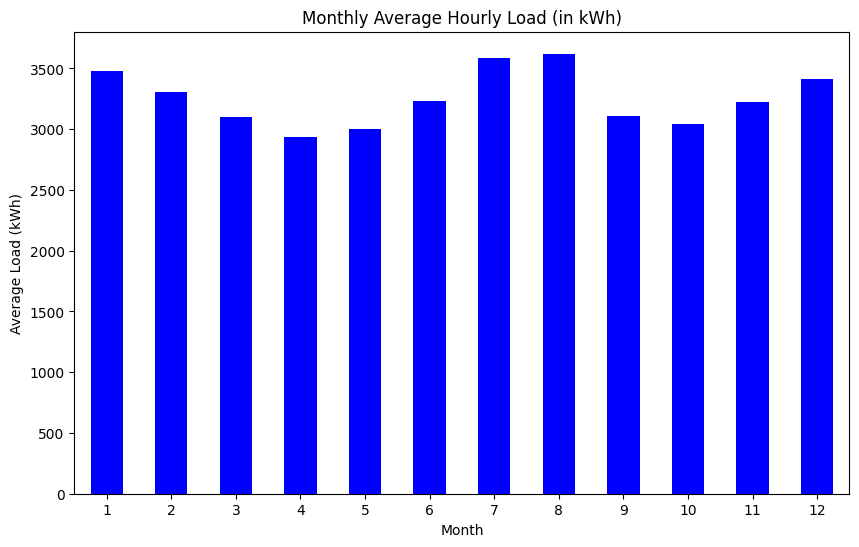

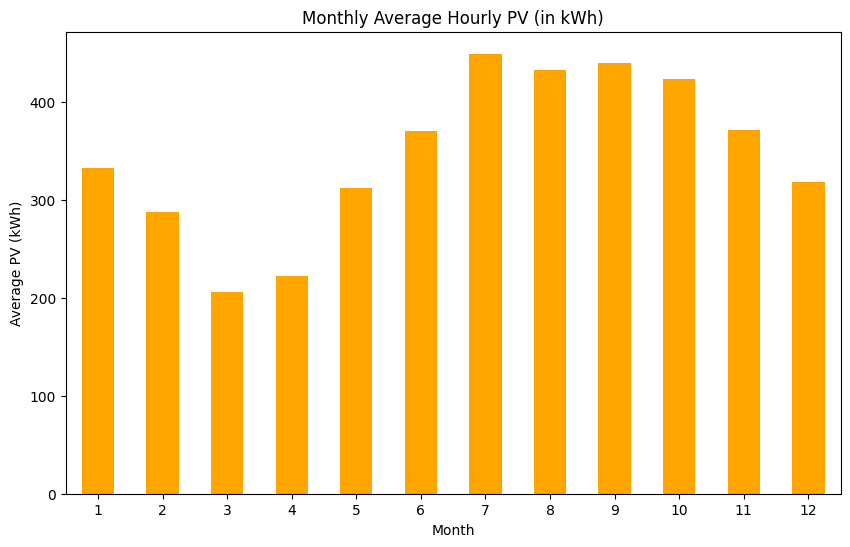

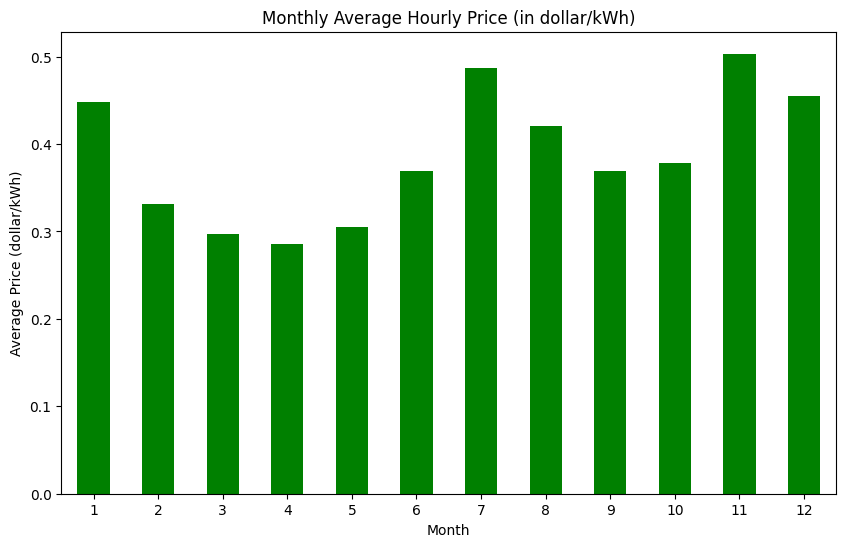

In [48]:
# Some other good plots
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Month'] = data['Timestamp'].dt.month

# Monthly Average Hourly Load Distribution
monthly_avg_load = data.groupby('Month')['Load (kWh)'].mean()
monthly_avg_load.plot(kind='bar', color='blue', figsize=(10, 6))
plt.title('Monthly Average Hourly Load (in kWh)')
plt.xlabel('Month')
plt.ylabel('Average Load (kWh)')
plt.xticks(rotation=0)
plt.show()


# Monthly Average Hourly PV Distribution
monthly_avg_pv = data.groupby('Month')['PV (kWh)'].mean()
monthly_avg_pv.plot(kind='bar', color='orange', figsize=(10, 6))
plt.title('Monthly Average Hourly PV (in kWh)')
plt.xlabel('Month')
plt.ylabel('Average PV (kWh)')
plt.xticks(rotation=0)
plt.show()

# Monthly Average Hourly Price Distribution
monthly_avg_price = data.groupby('Month')['price (dollar/kWh)'].mean()
monthly_avg_price.plot(kind='bar', color='green', figsize=(10, 6))
plt.title('Monthly Average Hourly Price (in dollar/kWh)')
plt.xlabel('Month')
plt.ylabel('Average Price (dollar/kWh)')
plt.xticks(rotation=0)
plt.show()

Overall, data is clean and has some really good years' worth of data in terms of PV, Wind, Load and Price. It also has Carbon Emissions' Data which could be extremely useful for the Reward/Cost function for RL Training.

I also found a Master Dataset for this which contains Weather Data as well: https://github.com/FLYao123/Dataset-2---A-Microgrid-Energy-System

In [32]:
final_data = pd.read_csv('Weather_factors_and_material_all.csv')

In [33]:
final_data

,datetime,temp,feelslike,humidity,precip,windspeed,sealevelpressure,cloudcover,visibility,purchasing price (dollar/kWh),...,Load (kWh),PV (kWh),CI(gco2/kWh),Hour,Weekday,Month,Natural Gas Price ($/M Btu),Crude Oil (($/Barrel)),No. 2 Heating Oil ($/Gallon),No. 2 Diesel Fuel (($/Gallon))
0,2012-01-01T00:00:00,-4.0,-11.3,49.86,0.0,26.7,1024.9,41.6,16.0,0.3168,...,2698,0.000000,184,0,1,1,2.97,102.96,3.040,3.087
1,2012-01-01T01:00:00,-4.1,-11.2,50.05,0.0,25.5,1025.5,97.9,16.0,0.2988,...,2558,0.000000,182,1,1,1,2.97,102.96,3.040,3.087
2,2012-01-01T02:00:00,-3.2,-11.1,46.07,0.0,34.2,1026.0,100.0,16.0,0.2701,...,2444,0.000000,171,2,1,1,2.97,102.96,3.040,3.087
3,2012-01-01T03:00:00,-3.1,-11.5,46.33,0.0,40.0,1026.8,100.0,16.0,0.2606,...,2402,0.000000,169,3,1,1,2.97,102.96,3.040,3.087
4,2012-01-01T04:00:00,-4.1,-12.6,50.07,0.0,37.8,1027.9,19.5,16.0,0.2564,...,2403,0.000000,159,4,1,1,2.97,102.96,3.040,3.087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,2012-12-31T19:00:00,-10.3,-10.3,80.94,0.0,0.0,1021.4,100.0,10.0,0.8394,...,3769,0.258288,126,19,2,12,3.43,91.83,3.044,3.074
8780,2012-12-31T20:00:00,-10.9,-14.7,84.82,0.0,6.3,1020.9,100.0,10.8,0.7951,...,3585,0.000000,115,20,2,12,3.43,91.83,3.044,3.074
8781,2012-12-31T21:00:00,-11.6,-16.1,80.03,0.0,7.5,1021.3,100.0,10.8,0.7313,...,3407,0.000000,99,21,2,12,3.43,91.83,3.044,3.074
8782,2012-12-31T22:00:00,-11.8,-15.0,81.03,0.0,5.1,1021.4,100.0,11.1,0.7010,...,3219,0.000000,85,22,2,12,3.43,91.83,3.044,3.074


In [43]:
final_data.columns #get the columns

Index(['datetime', 'temp', 'feelslike', 'humidity', 'precip', 'windspeed',
       'sealevelpressure', 'cloudcover', 'visibility',
       'purchasing price (dollar/kWh)', 'Unmet(kWh)', 'Load (kWh)', 'PV (kWh)',
       'CI(gco2/kWh)', 'Hour', 'Weekday', 'Month',
       'Natural Gas Price ($/M Btu)', 'Crude Oil (($/Barrel))',
       'No. 2 Heating Oil ($/Gallon)', 'No. 2 Diesel Fuel (($/Gallon))'],
      dtype='object')

New data on weather and price of oil, fuel, etc.

Extremely useful for forecasting and in-depth reward functions.

In [44]:
final_data.isna().sum() #check for null values

,0
datetime,0
temp,0
feelslike,0
humidity,0
precip,0
windspeed,0
sealevelpressure,0
cloudcover,0
visibility,0
purchasing price (dollar/kWh),0


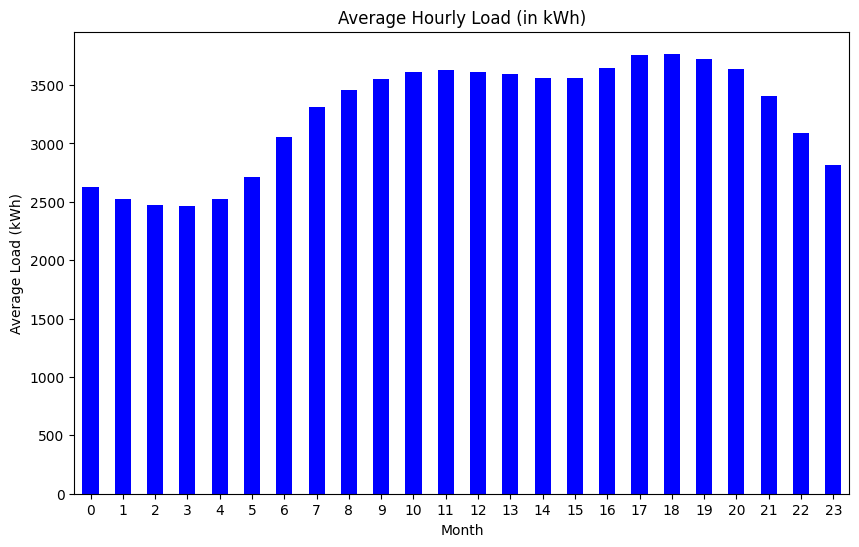

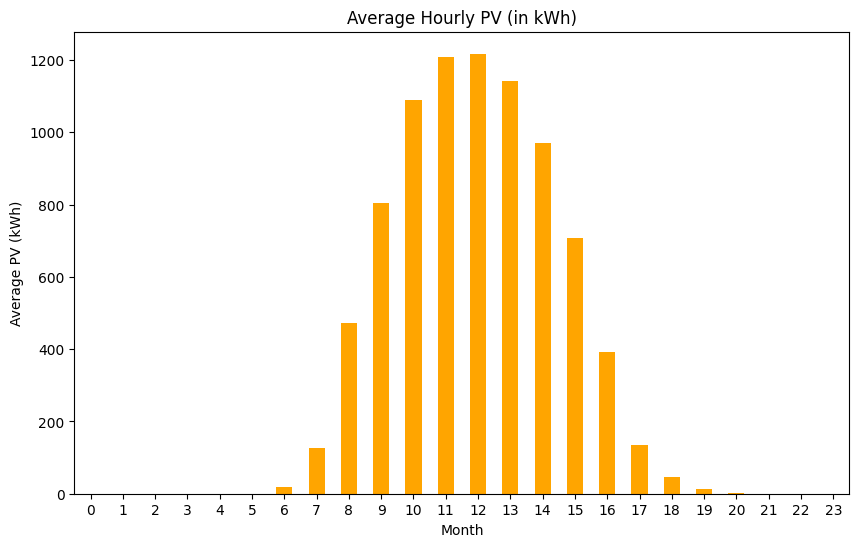

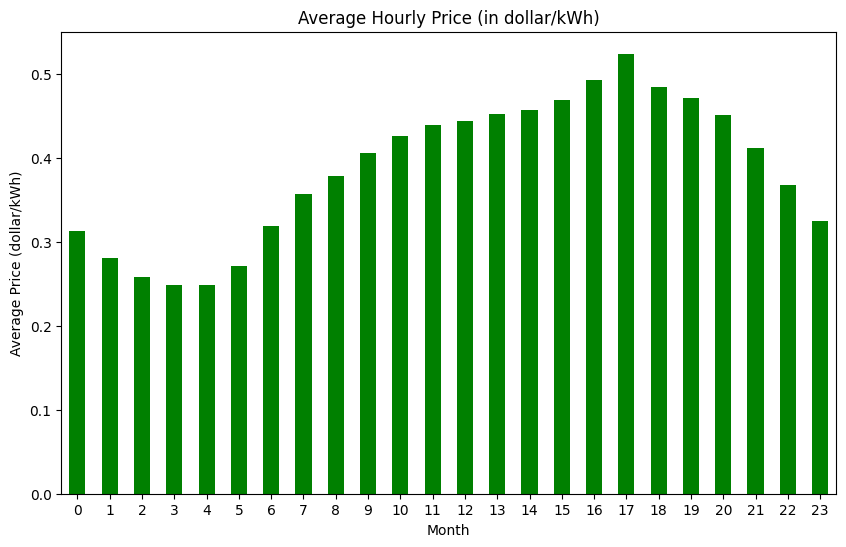

In [47]:
# Average Hourly Load Distribution
hourly_avg_load = final_data.groupby('Hour')['Load (kWh)'].mean()
hourly_avg_load.plot(kind='bar', color='blue', figsize=(10, 6))
plt.title('Average Hourly Load (in kWh)')
plt.xlabel('Month')
plt.ylabel('Average Load (kWh)')
plt.xticks(rotation=0)
plt.show()


# Average Hourly PV Distribution
hourly_avg_pv = final_data.groupby('Hour')['PV (kWh)'].mean()
hourly_avg_pv.plot(kind='bar', color='orange', figsize=(10, 6))
plt.title('Average Hourly PV (in kWh)')
plt.xlabel('Month')
plt.ylabel('Average PV (kWh)')
plt.xticks(rotation=0)
plt.show()

# Average Hourly Price Distribution
hourly_avg_price = final_data.groupby('Hour')['purchasing price (dollar/kWh)'].mean()
hourly_avg_price.plot(kind='bar', color='green', figsize=(10, 6))
plt.title('Average Hourly Price (in dollar/kWh)')
plt.xlabel('Month')
plt.ylabel('Average Price (dollar/kWh)')
plt.xticks(rotation=0)
plt.show()

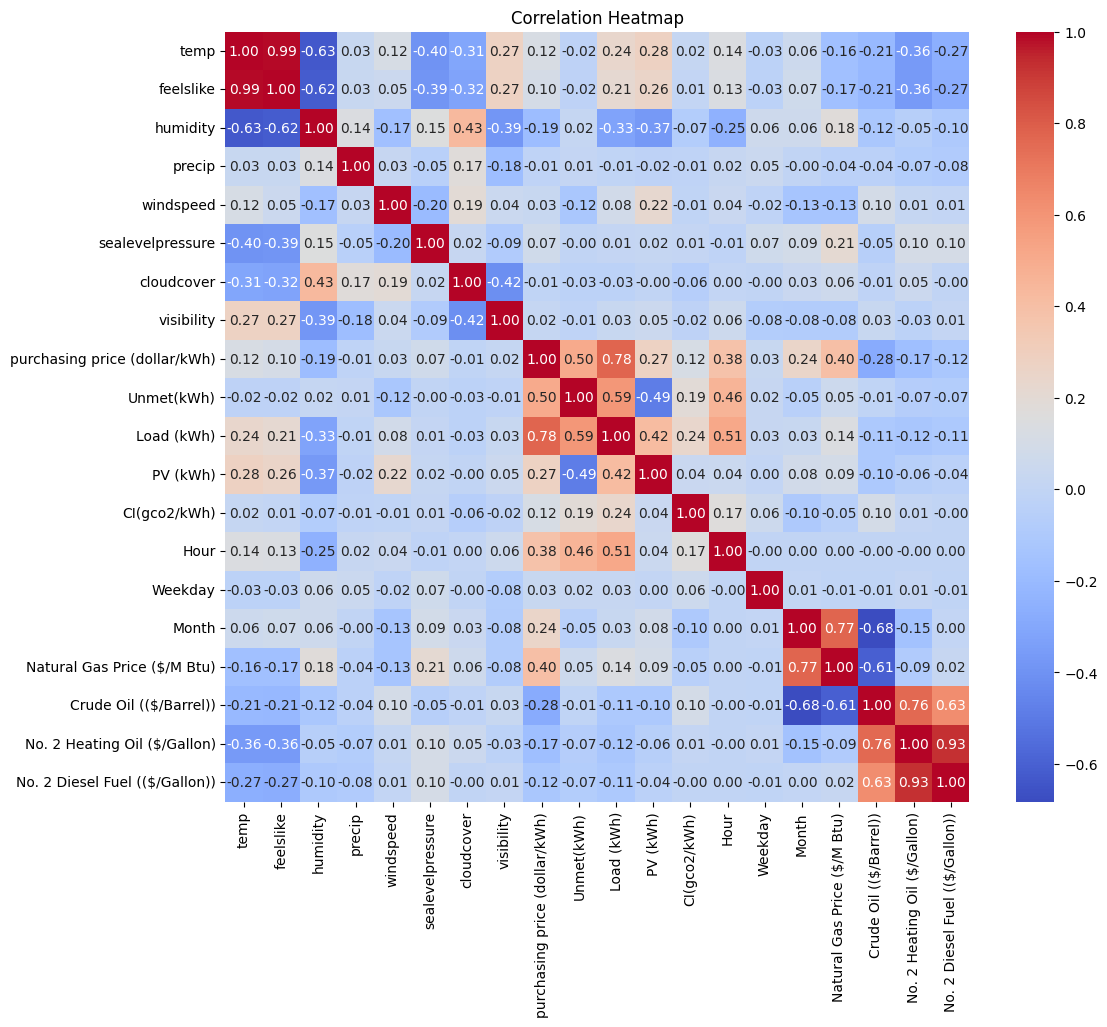

In [41]:
# Correlation Heat Map for all variables
correlation_matrix = final_data.drop(['datetime'], axis=1).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()